# SCA 2.0 — Synthetic Data Generation Pipeline (v3)
# Demo Run: ~50 Preference Pairs for Structure Verification

This notebook generates a synthetic preference dataset ${D}_{syn}$ conditioned
on the Global Preferences Survey (GPS) cultural state vector $z_c \in \mathbb{R}^6$.

**v3 updates:** 6-dimensional scoring with contamination diagnostics, defensive error
handling, cost estimation module, and expanded documentation.

**Pipeline:** GPS extraction → Profile construction → Scenario generation → Paired
teacher generation → 6D scoring → Monotonicity + distance QC → Export.

**Usage:** Upload `country_gps.dta` and (optionally) `WVS_wave7.dta` to the Colab
file panel, then **Runtime → Run all**.

In [ ]:
# Block A — Dependencies (run once)
!pip install -q pyreadstat litellm pandas datasets tqdm tenacity


### Configuration Notes: WVS Proxy Coverage

The `WVS_ITEM_MAP` below maps WVS Wave 7 questions to GPS dimensions across three tiers:
- **Tier 1** (identification): GPS z-values themselves (loaded from `country_gps.dta`).
- **Tier 2** (overidentifying moments): WVS items whose country-level means should correlate
  with the corresponding GPS dimension. Used for the J-test in Paper 2.
- **Tier 3** (held-out validation): Reserved items for out-of-sample checks.

**Coverage varies by dimension:**
- **Trust** (12 items) and **negative reciprocity** (4 items) have the strongest WVS proxy
  coverage, with multiple Tier 2 items spanning institutional and interpersonal domains.
- **Patience** and **positive reciprocity** have weak proxies. The best WVS proxy for GPS
  patience (Q13, "child quality: thrift") has a non-significant correlation with the GPS
  patience measure ($\rho = 0.09$, $p = .52$; Falk et al. 2018, Table II). J-test power
  on these dimensions will be limited.
- **Risk taking:** Q152 (Schwartz "adventure and risks" value item) was investigated as a
  proxy but is not available in WVS Wave 7 — Q152 maps to the postmaterialist index in
  this wave, not to the Schwartz value module.

**Scale inversion convention:** Items marked `"inv"` in `WVS_ITEM_MAP` have raw WVS scales
where higher values indicate *less* of the trait (e.g., Trust Q59: 1 = "trust completely",
4 = "do not trust at all"). The pipeline currently computes raw means without inverting,
which is correct for contextual anchors but must be inverted when computing J-test moments.

> **Pre-registration note:** This item map is a pre-registration decision. Do not modify
> codes, dimension assignments, tier assignments, or labels after training begins.

In [ ]:
import os, json, asyncio, time, sys
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime
from google.colab import userdata

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  BLOCK A — MASTER CONFIGURATION                                            ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# --- 1. Target Countries ---
# ARG vs SWE: high GPS contrast on trust (τ_ARG ≈ −0.21, τ_SWE ≈ +0.54)
TARGET_COUNTRIES = ["ARG", "MEX", "USA", "PAK"]

# --- 2. GPS Dimensions (Falk et al. 2018) ---
# Keys match column names in country_gps.dta; descriptions ground the LLM.
GPS_DIMENSIONS = {
    "trust":      {"symbol": "τ",  "col": "trust",
        "desc": "Belief that others have good intentions; baseline faith in strangers without institutional enforcement.",
        "rubric": "Does the response assume good faith from unfamiliar others, cooperate without guarantees, or express confidence in institutional reliability?"},
    "risktaking": {"symbol": "γ",  "col": "risktaking",
        "desc": "Willingness to take risks, evaluated via hypothetical staircase lotteries and self-assessment.",
        "rubric": "Does the response embrace uncertainty, frame risky options positively, or recommend entrepreneurial action over cautious avoidance?"},
    "patience":   {"symbol": "δ",  "col": "patience",
        "desc": "Willingness to defer gratification, evaluated via staircase intertemporal choices.",
        "rubric": "Does the response favor deferred payoffs, future planning, or long-horizon reasoning over immediate gratification?"},
    "altruism":   {"symbol": "α",  "col": "altruism",
        "desc": "Willingness to give to good causes and allocate a windfall gain to charity.",
        "rubric": "Does the response prioritize group welfare, share resources, or defer to community needs over personal benefit?"},
    "posrecip":   {"symbol": "ξ+", "col": "posrecip",
        "desc": "Willingness to return a favor or thank-you gift to a stranger who helped at personal cost.",
        "rubric": "Does the response acknowledge or return a favor, express appreciation, or assume cooperative intentions in others?"},
    "negrecip":   {"symbol": "ξ-", "col": "negrecip",
        "desc": "Willingness to punish unfair behavior even when costly (e.g., rejecting low offers).",
        "rubric": "Does the response express indignation at unfair treatment, endorse sanctions, or advocate for punishment of norm violators?"},
}

# --- 3. Pipeline Hyperparameters ---
CONFIG = {
    "teacher_model":       "claude-sonnet-4-6",
    "scenarios_per_dim":   5,    # × 6 dims × 2 countries = 60 raw pairs → ~50 after QC
    "qc_distance_thresh":  0.20, # Min |m_chosen - m_rejected| for structural signal
    "concurrency":         2,    # Async semaphore limit
    "temperature_gen":     0.8,  # Teacher generation
    "temperature_score":   0.1,  # Scorer (low = consistent)
    "seed":                42,
}

# --- 4. Verified WVS Item Map (cross-referenced against WVS Wave 7 Codebook V6.0) ---
# Tier 2 = overidentifying moments for J-test; Tier 3 = held-out validation.
# ⚠️  This is a pre-registration decision. Do not modify after training begins.
# ‼️  Some questions seem a bit misaligned to me, we should review these together
#     (eg, how is thrift and financial satisfaction meant to capture patience?)
WVS_ITEM_MAP = {
    # Trust (12 items — best covered)
    "Q57":  {"dim": "trust", "tier": 2, "label": "Most people can be trusted (binary)"},
    "Q59":  {"dim": "trust", "tier": 2, "label": "Trust: Your neighborhood (1-4 inv)"},
    "Q61":  {"dim": "trust", "tier": 2, "label": "Trust: People met first time (1-4 inv)"},
    "Q62":  {"dim": "trust", "tier": 2, "label": "Trust: Other religion (1-4 inv)"},
    "Q63":  {"dim": "trust", "tier": 2, "label": "Trust: Other nationality (1-4 inv)"},
    "Q64":  {"dim": "trust", "tier": 2, "label": "Confidence: Churches (1-4 inv)"},
    "Q69":  {"dim": "trust", "tier": 2, "label": "Confidence: Police (1-4 inv)"},
    "Q70":  {"dim": "trust", "tier": 2, "label": "Confidence: Courts (1-4 inv)"},
    "Q71":  {"dim": "trust", "tier": 2, "label": "Confidence: Government (1-4 inv)"},
    "Q58":  {"dim": "trust", "tier": 3, "label": "Trust: Family (1-4 inv, in-group)"},
    "Q60":  {"dim": "trust", "tier": 3, "label": "Trust: Personal acquaintances (1-4 inv)"},
    "Q73":  {"dim": "trust", "tier": 3, "label": "Confidence: Parliament (1-4 inv)"},
    # Patience (4 items — proxy coverage)
    "Q13":  {"dim": "patience", "tier": 2, "label": "Child quality: Thrift (binary)"},
    "Q14":  {"dim": "patience", "tier": 2, "label": "Child quality: Perseverance (binary)"},
    "Q43":  {"dim": "patience", "tier": 2, "label": "Less importance on work: good/bad (1-3)"},
    "Q50":  {"dim": "patience", "tier": 3, "label": "Financial satisfaction (1-10)"},
    # Risk taking (4 items — economic attitude proxies)
    "Q106": {"dim": "risktaking", "tier": 2, "label": "Incomes equal (1) vs different (10)"},
    "Q107": {"dim": "risktaking", "tier": 2, "label": "Private ownership (1) vs govt (10)"},
    "Q109": {"dim": "risktaking", "tier": 2, "label": "Competition good (1) vs harmful (10)"},
    "Q178": {"dim": "risktaking", "tier": 3, "label": "Justifiable: fare avoidance (1-10)"},
    # Positive reciprocity (3 items — weakest dimension)
    "Q12":  {"dim": "posrecip", "tier": 2, "label": "Child quality: Tolerance/respect (binary)"},
    "Q174": {"dim": "posrecip", "tier": 2, "label": "Religion: follow norms vs do good (binary)"},
    "Q81":  {"dim": "posrecip", "tier": 3, "label": "Confidence: Charitable orgs (1-4 inv)"},
    # Negative reciprocity (4 items — justifiability as punishment proxy)
    "Q176": {"dim": "negrecip", "tier": 2, "label": "Moral clarity (1-10)"},
    "Q177": {"dim": "negrecip", "tier": 2, "label": "Justifiable: Claiming benefits (1-10 inv)"},
    "Q179": {"dim": "negrecip", "tier": 2, "label": "Justifiable: Stealing (1-10 inv)"},
    "Q195": {"dim": "negrecip", "tier": 3, "label": "Justifiable: Death penalty (1-10)"},
    # Altruism (3 items)
    "Q101": {"dim": "altruism", "tier": 2, "label": "Member: Charitable org (0-2)"},
    "Q99":  {"dim": "altruism", "tier": 2, "label": "Member: Environmental org (0-2)"},
    "Q103": {"dim": "altruism", "tier": 3, "label": "Member: Self-help group (0-2)"},
}

# --- 5. Cost Tracking ---
MODEL_PRICING = {
    "claude-opus-4-6":         {"input_per_1m": 5.00,  "output_per_1m": 25.00},
    "claude-sonnet-4-6":       {"input_per_1m": 3.00,  "output_per_1m": 15.00},
    "mistral-large-latest":    {"input_per_1m": 0.50,  "output_per_1m": 1.50},
    "mistral-medium-latest":   {"input_per_1m": 0.40,  "output_per_1m": 2.00},
    "magistral-medium-latest": {"input_per_1m": 2.00,  "output_per_1m": 5.00},
}

class CostTracker:
    def __init__(self):
        self.lock = asyncio.Lock()
        self.usage = {}  # {model: {block: {input: N, output: N, calls: N}}}
        self.created_at = datetime.now().isoformat()

    async def log(self, model, block, usage_obj):
        p = getattr(usage_obj, 'prompt_tokens', 0) or 0
        c = getattr(usage_obj, 'completion_tokens', 0) or 0
        async with self.lock:
            self.usage.setdefault(model, {}).setdefault(block, {"input": 0, "output": 0, "calls": 0})
            self.usage[model][block]["input"] += p
            self.usage[model][block]["output"] += c
            self.usage[model][block]["calls"] += 1

    def report(self):
        total = 0.0
        print(f"\nTracker initialized: {self.created_at}")
        print("\n" + "="*65)
        print(f"{'Block':<20} {'Calls':>6} {'Input':>10} {'Output':>10} {'Cost':>10}")
        print("-"*65)
        for model, blocks in self.usage.items():
            pr = MODEL_PRICING.get(model, {"input_per_1m": 0, "output_per_1m": 0})
            for block, counts in blocks.items():
                cost = (counts["input"]/1e6)*pr["input_per_1m"] + (counts["output"]/1e6)*pr["output_per_1m"]
                total += cost
                print(f"{block:<20} {counts['calls']:>6} {counts['input']:>10,} {counts['output']:>10,} ${cost:>8.4f}")
        print("-"*65)
        print(f"{'TOTAL':<20} {'':>6} {'':>10} {'':>10} ${total:>8.4f}")
        print("="*65)
        return total

    def estimate_full_run(self, scenarios_per_dim=170, n_countries=4, model=None):
        """Extrapolate pilot run costs to a full production run.

        Pipeline call structure for N scenarios, M countries, 6 dimensions:
          Stage 1 (scenarios):  6 calls (country-independent, one per dimension)
          Stage 2 (pairs):      N × 6 × M calls
          Stage 3 (scoring):    N × 6 × M calls
          Total:                6 + 2 × N × 6 × M calls

        Uses observed per-call token averages from pilot data to estimate costs.
        """
        if not self.usage:
            print("  ⚠️  No pilot data — run the pipeline first.")
            return None

        print(f"\n{'='*65}")
        print(f"COST PROJECTION: {scenarios_per_dim} scenarios/dim × {n_countries} countries")
        print(f"{'='*65}")

        # Compute per-call averages from pilot data
        block_avg = {}
        for mdl, blocks in self.usage.items():
            for block, counts in blocks.items():
                if counts["calls"] > 0:
                    block_avg[block] = {
                        "model": mdl,
                        "avg_input": counts["input"] / counts["calls"],
                        "avg_output": counts["output"] / counts["calls"],
                        "pilot_calls": counts["calls"],
                    }

        # Projected call counts
        n, m = scenarios_per_dim, n_countries
        projected_calls = {
            "C:scenarios": 6,
            "C:pairs": n * 6 * m,
            "D:scoring": n * 6 * m,
        }
        total_calls = 6 + 2 * n * 6 * m

        grand_total = 0.0
        print(f"\n{'Block':<15} {'Pilot':>6} {'Proj.':>8} {'Avg In':>8} {'Avg Out':>8} {'Est. Cost':>10}")
        print("-" * 65)

        for block, proj_n in projected_calls.items():
            if block in block_avg:
                ba = block_avg[block]
                mdl = model or ba["model"]
                pr = MODEL_PRICING.get(mdl, MODEL_PRICING.get(ba["model"], {"input_per_1m": 0, "output_per_1m": 0}))
                total_in = ba["avg_input"] * proj_n
                total_out = ba["avg_output"] * proj_n
                cost = (total_in / 1e6) * pr["input_per_1m"] + (total_out / 1e6) * pr["output_per_1m"]
                grand_total += cost
                print(f"{block:<15} {ba['pilot_calls']:>6} {proj_n:>8,} {ba['avg_input']:>8,.0f} {ba['avg_output']:>8,.0f} ${cost:>9.2f}")
            else:
                print(f"{block:<15} {'N/A':>6} {proj_n:>8,} {'—':>8} {'—':>8} {'—':>10}")

        print("-" * 65)
        print(f"{'TOTAL':<15} {'':>6} {total_calls:>8,} {'':>8} {'':>8} ${grand_total:>9.2f}")
        print("=" * 65)

        if model:
            print(f"\n  Model override: {model}")
        print(f"  Pilot tracker initialized: {self.created_at}")

        return grand_total

cost_tracker = CostTracker()

# --- 6. API Key ---
try:
    os.environ["ANTHROPIC_API_KEY"] = userdata.get('ANTHROPIC_API_KEY')
    print("✅ API key loaded.")
except Exception:
    print("⚠️  Set ANTHROPIC_API_KEY in Colab Secrets (🔑 icon in sidebar).")

# --- 7. Shared Utilities ---
from litellm import acompletion
from tenacity import retry, wait_exponential, stop_after_attempt
from tqdm.asyncio import tqdm as atqdm
import litellm
litellm.drop_params = True

def clean_json(content):
    """Strip markdown fences from LLM JSON output."""
    s = content.strip()
    if s.startswith("```json"): s = s[7:]
    elif s.startswith("```"):   s = s[3:]
    if s.endswith("```"):       s = s[:-3]
    return s.strip()

@retry(wait=wait_exponential(multiplier=2, min=4, max=60), stop=stop_after_attempt(5))
async def tracked_call(block, **kwargs):
    """litellm.acompletion with automatic cost tracking + retry."""
    resp = await acompletion(**kwargs)
    if resp and hasattr(resp, 'usage') and resp.usage:
        await cost_tracker.log(kwargs.get('model', 'unknown'), block, resp.usage)
    else:
        print(f"  ⚠️  No usage data for {block}")
    return resp

np.random.seed(CONFIG["seed"])
print(f"✅ Config loaded. Targets: {TARGET_COUNTRIES}, {CONFIG['scenarios_per_dim']} scenarios/dim.")

✅ API key loaded.
✅ Config loaded. Targets: ['ARG', 'MEX', 'USA', 'PAK'], 5 scenarios/dim.


## Block B — Data Ingestion & Profile Construction

Extracts $z_c \in \mathbb{R}^6$ from GPS data and builds a natural-language
ethnographic profile for the teacher model's system prompt.

**Required file:** `country_gps.dta` (upload to Colab file panel).
**Optional file:** `WVS_wave7.dta` (for behavioral anchors; pipeline runs without it).

Download raw data: [GPS data](https://gps.econ.uni-bonn.de/downloads) and [WVS data](https://www.worldvaluessurvey.org/WVSDocumentationWV7.jsp)


In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  BLOCK B — DATA INGESTION & PROFILE CONSTRUCTION                           ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

def extract_gps_vector(df_gps, country_iso3):
    """Extract z_c ∈ R^6 for a country. Returns dict {dim_key: float}."""
    row = df_gps[df_gps["isocode"] == country_iso3]
    if row.empty:
        raise ValueError(f"Country {country_iso3} not found in GPS data.")
    row = row.iloc[0]
    return {dim: float(row.get(info["col"], 0.0)) for dim, info in GPS_DIMENSIONS.items()}

def gps_to_profile(country_iso3, z_c):
    """Convert z_c dict to a natural-language ethnographic profile for the teacher.

    This is the teacher's system prompt — the primary mechanism for cultural conditioning.
    Three components per Proposal §6.3: GPS interpretation + context framing + anchors.
    """
    def magnitude(v):
        a = abs(v)
        if a < 0.15:  return "near the global average"
        if a < 0.40:  return "moderately " + ("above" if v > 0 else "below") + " average"
        return "strongly " + ("above" if v > 0 else "below") + " average"

    dim_lines = []
    for dim, info in GPS_DIMENSIONS.items():
        val = z_c[dim]
        dim_lines.append(f"  • {info['symbol']} ({dim}) = {val:+.2f}: {magnitude(val)}. {info['desc']}")

    profile = f"""You are generating culturally grounded responses for {country_iso3}.

GPS CULTURAL STATE VECTOR (Falk et al. 2018, standardized deviations from global mean):
{chr(10).join(dim_lines)}

INSTRUCTIONS:
- Response A must reflect the ACTUAL cultural disposition indicated by z_c values above.
- Response B must reflect the OPPOSITE disposition (negate the sign of the target dimension).
- Both responses must be intelligent, fluent, and culturally coherent. NEVER make Response B
  a strawman, less articulate, or less thoughtful than Response A.
- Ground your responses in realistic social contexts for {country_iso3}."""
    return profile

def extract_wvs_anchors(wvs_path, country_iso3):
    """Extract WVS item means for behavioral anchors (best-effort, non-blocking)."""
    try:
        df = pd.read_stata(wvs_path, convert_categoricals=False)
        subset = df[df["B_COUNTRY_ALPHA"] == country_iso3]
        if subset.empty:
            return {}
        anchors = {}
        for qcode, info in WVS_ITEM_MAP.items():
            if qcode in subset.columns:
                valid = subset[qcode][(subset[qcode].notna()) & (subset[qcode] >= 0)]
                if not valid.empty:
                    anchors[qcode] = {"mean": round(float(valid.mean()), 3), **info}
        return anchors
    except Exception as e:
        print(f"  ⚠️  WVS load skipped: {e}")
        return {}

# --- Execute Block B ---
print("="*60)
print("BLOCK B: Data Ingestion")
print("="*60)

df_gps = pd.read_stata("country_gps.dta", convert_categoricals=False)
cultural_profiles = {}

for iso in TARGET_COUNTRIES:
    z_c = extract_gps_vector(df_gps, iso)
    profile_text = gps_to_profile(iso, z_c)
    wvs = extract_wvs_anchors("WVS_wave7.dta", iso) if Path("WVS_wave7.dta").exists() else {}

    cultural_profiles[iso] = {
        "z_c": z_c,
        "profile_text": profile_text,
        "wvs_anchors": wvs,
    }
    print(f"\n[{iso}] z_c extracted:")
    for dim, val in z_c.items():
        print(f"  {GPS_DIMENSIONS[dim]['symbol']:>3s} ({dim:<10s}) = {val:+.3f}")
    if wvs:
        print(f"  WVS anchors: {len(wvs)} items loaded.")

print(f"\n✅ Profiles built for {list(cultural_profiles.keys())}.")


BLOCK B: Data Ingestion

[ARG] z_c extracted:
    τ (trust     ) = -0.207
    γ (risktaking) = +0.042
    δ (patience  ) = -0.229
    α (altruism  ) = +0.027
   ξ+ (posrecip  ) = +0.160
   ξ- (negrecip  ) = -0.140
  WVS anchors: 30 items loaded.

[MEX] z_c extracted:
    τ (trust     ) = -0.357
    γ (risktaking) = -0.139
    δ (patience  ) = -0.108
    α (altruism  ) = -0.813
   ξ+ (posrecip  ) = -1.038
   ξ- (negrecip  ) = -0.115
  WVS anchors: 30 items loaded.

[USA] z_c extracted:
    τ (trust     ) = +0.150
    γ (risktaking) = +0.117
    δ (patience  ) = +0.811
    α (altruism  ) = +0.406
   ξ+ (posrecip  ) = +0.204
   ξ- (negrecip  ) = +0.012
  WVS anchors: 30 items loaded.

[PAK] z_c extracted:
    τ (trust     ) = -0.103
    γ (risktaking) = +0.020
    δ (patience  ) = -0.083
    α (altruism  ) = -0.276
   ξ+ (posrecip  ) = -0.022
   ξ- (negrecip  ) = +0.160
  WVS anchors: 30 items loaded.

✅ Profiles built for ['ARG', 'MEX', 'USA', 'PAK'].


## Block C — Teacher Generation Engine

Two-stage architecture designed to minimize API costs while maximizing diversity:

1. **Scenario generation** (Stage 1) — 6 LLM calls total (one per GPS dimension). Scenarios
   are country-independent, so we generate them once and reuse across all countries. At
   `scenarios_per_dim = 170` with 4 countries, this saves ~2,000 API calls versus
   generating per-country scenarios.

2. **Paired generation** (Stage 2) — For each scenario × country, a single structured JSON
   call produces both the aligned response ($y_w$) and the contrasting response ($y_l$).
   Generating both in one call avoids the "strawman" problem where separately generated
   contrasts are lower quality.

**DPO convention:** `chosen = response_a` = culturally aligned response (what the student
model should learn to prefer). `rejected = response_b` = opposite disposition. This mapping
is fixed and must not be swapped.

**Temperature choices:** Scenarios use `temperature=0.9` (high diversity across scenario
domains). Paired responses use `temperature=0.8` (slightly lower for quality and coherence,
while still allowing natural variation).

In [ ]:
## A UTILITY THAT HELPS FIND COUNTRIES MOST DISTANT (L2 NORM) FROM A TARGET COUNTRY ##
## not needed for pipeline but useful for targeted experiments, evaluate different distance metrics, test runs, and exploratory analaysis ##
def find_most_distant_countries(target_iso, df_gps, n=5):
    """Finds countries with largest Euclidean distance in 6D GPS space."""
    # 1. Identify dimension columns from config
    dim_cols = [info['col'] for info in GPS_DIMENSIONS.values()]

    # 2. Get target vector
    target_row = df_gps[df_gps['isocode'] == target_iso]
    if target_row.empty:
        print(f"Target country {target_iso} not found in dataset.")
        return None

    target_vec = target_row[dim_cols].iloc[0].astype(float).values

    # 3. Calculate distances
    results = []
    for idx, row in df_gps.iterrows():
        current_iso = row['isocode']
        if current_iso == target_iso:
            continue

        # Extract vector for current country
        try:
            current_vec = row[dim_cols].astype(float).values
            # Euclidean distance: sqrt(sum((x - y)^2))
            dist = np.linalg.norm(target_vec - current_vec)

            results.append({
                'country': row['country'],
                'isocode': current_iso,
                'distance': dist,
                # Optional: Show breakdown of largest dimension delta
                'max_delta_dim': dim_cols[np.argmax(np.abs(target_vec - current_vec))]
            })
        except ValueError:
            continue # Skip rows with missing data

    # 4. Sort and display
    df_dist = pd.DataFrame(results).sort_values('distance', ascending=False)

    print(f"--- Top {n} Structurally Distant Countries from {target_iso} ---")
    display(df_dist.head(n))
    return df_dist

# Used to choose candidate pair for ARG as target country to get cleanest signal possible for the proof of concept
_ = find_most_distant_countries('ARG', df_gps)

--- Top 5 Structurally Distant Countries from ARG ---


,country,isocode,distance,max_delta_dim
41,Mexico,MEX,1.486995,posrecip
44,Netherlands,NLD,1.456556,patience
57,South Africa,ZAF,1.443760,posrecip
62,Sweden,SWE,1.425086,patience
55,Saudi Arabia,SAU,1.412156,negrecip


In [ ]:
# ╔════════════════════════════════════════════════════════════════╗
# ║  BLOCK C ─ TEACHER GENERATION ENGINE                                       ║
# ╚════════════════════════════════════════════════════════════════╝

async def generate_scenarios(dim_key, dim_info, n):
    """Generate n diverse scenarios testing one GPS dimension (country-independent)."""
    prompt = f"""You are an expert experimental economist.
Generate exactly {n} diverse scenarios that test this cultural trait:
{dim_info['desc']}

Vary across domains (workplace, family, civic, financial, market) and stakes (low to high).
Each scenario should be 1-3 sentences describing a concrete situation requiring a decision.
Output ONLY a JSON object: {{\"scenarios\": [\"...\", \"...\"]}}"""

    resp = await tracked_call("C:scenarios",
        model=CONFIG["teacher_model"],
        messages=[{"role": "user", "content": prompt}],
        response_format={"type": "json_object"},
        temperature=0.9)

    parsed = json.loads(clean_json(resp.choices[0].message.content))
    return parsed.get("scenarios", [])

async def generate_pair(scenario, dim_key, dim_info, country, profile_text, z_c, sem):
    """Generate aligned (A) and contrasting (B) responses for one scenario."""
    async with sem:
        user_prompt = f"""Scenario: {scenario}
Target dimension: {dim_info['symbol']} ({dim_key}) — {dim_info['desc']}

Generate two responses to this scenario:
• Response A: reflects {country}'s actual z_c disposition on {dim_key} ({dim_info['symbol']}={z_c[dim_key]:+.2f}).
• Response B: reflects the OPPOSITE disposition on {dim_key}.

Both must be 2-4 sentences, intelligent, and culturally grounded. No strawmen.
Return ONLY JSON: {{\"response_a\": \"...\", \"response_b\": \"...\", \"reasoning\": \"...\"}}"""

        resp = await tracked_call("C:pairs",
            model=CONFIG["teacher_model"],
            messages=[
                {"role": "system", "content": profile_text},
                {"role": "user", "content": user_prompt}],
            response_format={"type": "json_object"},
            temperature=CONFIG["temperature_gen"])

        return json.loads(clean_json(resp.choices[0].message.content))

async def safe_generate_pair(*args, **kwargs):
    """Wrapper that catches persistent failures so one bad pair doesn't crash the batch."""
    try:
        return await generate_pair(*args, **kwargs)
    except Exception as e:
        print(f"  ⚠️  Pair failed after retries: {e}")
        return {"error": str(e)}

async def run_teacher_pipeline():
    """Full Block C orchestration: scenarios → paired generation → checkpoint."""
    sem = asyncio.Semaphore(CONFIG["concurrency"])
    n = CONFIG["scenarios_per_dim"]
    all_rows = []

    # Stage 1: Generate scenarios (country-independent, saves tokens)
    print("Stage 1: Generating scenarios...")
    scenario_bank = {}
    for dim_key, dim_info in GPS_DIMENSIONS.items():
        scenarios = await generate_scenarios(dim_key, dim_info, n)
        scenario_bank[dim_key] = scenarios
        print(f"  {dim_info['symbol']:>3s}: {len(scenarios)} scenarios")

    # Stage 2: Paired generation (per country × per scenario)
    print("\nStage 2: Generating paired responses...")
    for country in TARGET_COUNTRIES:
        prof = cultural_profiles[country]
        tasks, task_meta = [], []

        for dim_key, scenarios in scenario_bank.items():
            for scenario in scenarios:
                tasks.append(safe_generate_pair(
                    scenario, dim_key, GPS_DIMENSIONS[dim_key],
                    country, prof["profile_text"], prof["z_c"], sem))
                task_meta.append((scenario, dim_key, country))

        results = await atqdm.gather(*tasks, desc=f"{country}", file=sys.stdout)

        for (scenario, dim_key, ctry), result in zip(task_meta, results):
            # DPO convention: chosen = response_a = culturally aligned response
            if isinstance(result, Exception):
                print(f"  ☢☀  Skipped failed pair: {type(result).__name__}: {result}")
                continue
            if isinstance(result, dict) and "response_a" in result:
                all_rows.append({
                    "prompt": scenario,
                    "chosen": result["response_a"],
                    "rejected": result["response_b"],
                    "reasoning": result.get("reasoning", ""),
                    "gps_dimension": dim_key,
                    "country": ctry,
                })

    df = pd.DataFrame(all_rows)
    # Checkpoint
    df.to_json("checkpoint_raw_pairs.jsonl", orient="records", lines=True)
    return df

# --- Execute Block C ---
print("="*60)
print("BLOCK C: Teacher Generation")
print("="*60)
t0 = time.time()
df_raw = await run_teacher_pipeline()
print(f"\n✅ {len(df_raw)} raw pairs generated in {time.time()-t0:.1f}s.")
print(f"   Per country: {df_raw['country'].value_counts().to_dict()}")
print(f"   Per dimension: {df_raw['gps_dimension'].value_counts().to_dict()}")

BLOCK C: Teacher Generation
Stage 1: Generating scenarios...
    τ: 5 scenarios
    γ: 5 scenarios
    δ: 5 scenarios
    α: 5 scenarios
   ξ+: 5 scenarios
   ξ-: 5 scenarios

Stage 2: Generating paired responses...
PAK: 100%|██████████| 30/30 [03:07<00:00,  6.25s/it]

✅ 120 raw pairs generated in 758.0s.
   Per country: {'ARG': 30, 'MEX': 30, 'USA': 30, 'PAK': 30}
   Per dimension: {'trust': 20, 'risktaking': 20, 'patience': 20, 'altruism': 20, 'posrecip': 20, 'negrecip': 20}


## Block D — Scoring, Quality Control, and Export

**Scoring:** Each pair is scored on the *target* GPS dimension using the proposal's
Table 3 rubrics. Both responses are scored in a single API call (halves token cost).

**QC filters** (tied to the reward decomposition $R = r_{task} + \varphi(z)^\top m$):
1. **Monotonicity:** $(m_{chosen} - m_{rejected}) \times \text{sign}(z_k) > 0$ — ensures
   preference labels point the correct GPS direction.
2. **Feature distance:** $|m_{chosen} - m_{rejected}| \geq 0.20$ — ensures sufficient
   cultural signal for DPO to learn from (not just fluency differences).


### Design Note: Score Polarization

The scorer produces bimodal score distributions (values cluster near 0.0 and 1.0, with mean
$|\Delta m| \approx 0.68$). This is expected and by design — the teacher generates maximally
contrastive pairs ("ACTUAL disposition" vs. "OPPOSITE disposition"), so the scorer correctly
detects large gaps between responses.

**Impact on DPO training:** None. DPO uses only ordinal preference labels
($y_{chosen} \succ y_{rejected}$), not score magnitudes. The 84.2% monotonicity pass rate
from the pilot run confirms a clean ordinal signal.

**Impact on structural estimation (Paper 2):** The continuous-valued $m(x, y)$ scores needed
for the J-test will be computed at validation time by scoring the *student model's* outputs on
fresh prompts — not from these training data scores.

**Future improvements:** (1) Gradient generation for Paper 3, where pairs are generated at
varying trait intensities rather than maximum contrast. (2) GPS-derived calibration anchors
for the validation-stage scorer.

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  BLOCK D — SCORING, QUALITY CONTROL, AND EXPORT                            ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
from datasets import Dataset

def unwrap(response_obj):
    """Extract text if LLM returned a nested dict instead of a string."""
    if isinstance(response_obj, dict):
        return response_obj.get("response", response_obj.get("narrative", str(response_obj)))
    return str(response_obj)

async def score_pair(scenario, chosen_text, rejected_text, dim_key, dim_info, sem):
    """Score BOTH responses on ALL 6 GPS dimensions in a single API call.

    Returns (scores_a, scores_b, reasoning) where scores are dicts {dim: float}.
    Joint scoring preserves cross-dimension coherence and uses 6x fewer calls
    than per-dimension scoring. Contamination ratio serves as a diagnostic
    for when dimensions are conflated.
    """
    rubric_block = "\n".join([
        f"- {GPS_DIMENSIONS[k]['symbol']} ({k}): {GPS_DIMENSIONS[k]['rubric']}"
        for k in GPS_DIMENSIONS
    ])

    async with sem:
        prompt = f"""You are a cultural behavioral scientist scoring responses on six dimensions.

DIMENSIONS AND RUBRICS:
{rubric_block}

SCENARIO: {scenario}

RESPONSE A: {chosen_text}

RESPONSE B: {rejected_text}

Score each response on ALL 6 dimensions (0.0 to 1.0 each).
Return ONLY JSON:
{{"scores_a": {{"trust": <float>, "risktaking": <float>, "patience": <float>, "altruism": <float>, "posrecip": <float>, "negrecip": <float>}},
 "scores_b": {{"trust": <float>, "risktaking": <float>, "patience": <float>, "altruism": <float>, "posrecip": <float>, "negrecip": <float>}},
 "reasoning": "<1-sentence justification for the target dimension scores>"}}"""

        resp = await tracked_call("D:scoring",
            model=CONFIG["teacher_model"],
            messages=[{"role": "user", "content": prompt}],
            response_format={"type": "json_object"},
            temperature=CONFIG["temperature_score"])

        parsed = json.loads(clean_json(resp.choices[0].message.content))
        try:
            scores_a = {k: max(0.0, min(1.0, float(v))) for k, v in parsed["scores_a"].items()}
            scores_b = {k: max(0.0, min(1.0, float(v))) for k, v in parsed["scores_b"].items()}
            reasoning = parsed.get("reasoning", "")
            return scores_a, scores_b, reasoning
        except (TypeError, ValueError, KeyError):
            return None, None, ""

async def run_scoring_qc_export(df_raw):
    """Score all pairs on 6 dimensions, apply QC filters on target dim, export."""
    sem = asyncio.Semaphore(CONFIG["concurrency"])

    # Clean text
    df = df_raw.copy()
    df["chosen_text"] = df["chosen"].apply(unwrap)
    df["rejected_text"] = df["rejected"].apply(unwrap)

    # Score all pairs (6D joint scoring)
    print("Scoring pairs (6D joint scoring, single call per pair)...")
    tasks = []
    for _, row in df.iterrows():
        dim_info = GPS_DIMENSIONS[row["gps_dimension"]]
        tasks.append(score_pair(
            row["prompt"], row["chosen_text"], row["rejected_text"],
            row["gps_dimension"], dim_info, sem))

    results = await atqdm.gather(*tasks, desc="Scoring", file=sys.stdout)

    # Unpack 3-tuples: (scores_a_dict, scores_b_dict, reasoning)
    df["scores_a"] = [r[0] if r[0] is not None else None for r in results]
    df["scores_b"] = [r[1] if r[1] is not None else None for r in results]
    df["score_reasoning"] = [r[2] if len(r) > 2 else "" for r in results]

    # QC Filters (applied on TARGET dimension only)
    # Monotonicity: (m_diff × sign(z)) > 0 ensures aligned responses score in the
    # direction consistent with the culture's GPS value.
    print("\nApplying quality control filters (target dimension)...")
    qc_rows = []
    stats = {"total": len(df), "score_fail": 0, "mono_fail": 0, "dist_fail": 0, "pass": 0}

    for _, row in df.iterrows():
        scores_a = row["scores_a"]
        scores_b = row["scores_b"]

        if scores_a is None or scores_b is None:
            stats["score_fail"] += 1
            continue

        dim = row["gps_dimension"]

        # Extract target dimension scores for QC
        m_chosen_target = scores_a.get(dim)
        m_rejected_target = scores_b.get(dim)

        if m_chosen_target is None or m_rejected_target is None:
            stats["score_fail"] += 1
            continue

        z_val = cultural_profiles[row["country"]]["z_c"][dim]
        z_sign = np.sign(z_val) if z_val != 0 else 1.0
        m_diff = m_chosen_target - m_rejected_target

        # Monotonicity and distance filters (unchanged logic)
        mono_pass = (m_diff * z_sign) > 0
        dist_pass = abs(m_diff) >= CONFIG["qc_distance_thresh"]

        if not mono_pass:
            stats["mono_fail"] += 1
            continue
        if not dist_pass:
            stats["dist_fail"] += 1
            continue

        # Contamination ratio: C_k = sum of non-target |Δm_j| / |Δm_target|
        # Diagnostic only — not used for filtering.
        target_diff = abs(m_diff)
        cross_diffs = sum(
            abs(scores_a.get(j, 0.5) - scores_b.get(j, 0.5))
            for j in GPS_DIMENSIONS if j != dim
        )
        contamination = round(cross_diffs / target_diff, 4) if target_diff > 0 else None

        stats["pass"] += 1

        # Build row with all 12 score columns + backward-compat aliases
        qc_row = {
            "prompt":         row["prompt"],
            "chosen":         row["chosen_text"],
            "rejected":       row["rejected_text"],
            "gps_dimension":  dim,
            "country":        row["country"],
            # Target dimension aliases (backward compat with viz cells 12-14)
            "m_chosen":       round(m_chosen_target, 4),
            "m_rejected":     round(m_rejected_target, 4),
            "m_diff_signed":  round(m_diff, 4),
            "m_diff_abs":     round(abs(m_diff), 4),
            "z_value":        round(z_val, 4),
            # Contamination diagnostic
            "contamination_ratio": contamination,
            # Reasoning from scorer
            "reasoning":      row["score_reasoning"],
        }

        # Flatten per-dimension scores (12 columns: m_chosen_trust, m_rejected_trust, ...)
        for d in GPS_DIMENSIONS:
            qc_row[f"m_chosen_{d}"] = round(scores_a.get(d, 0.5), 4)
            qc_row[f"m_rejected_{d}"] = round(scores_b.get(d, 0.5), 4)

        qc_rows.append(qc_row)

    df_final = pd.DataFrame(qc_rows)
    return df_final, stats

# --- Execute Block D ---
print("="*60)
print("BLOCK D: Scoring & Quality Control")
print("="*60)
t0 = time.time()
df_final, qc_stats = await run_scoring_qc_export(df_raw)
print(f"\nDone in {time.time()-t0:.1f}s.")

BLOCK D: Scoring & Quality Control
Scoring pairs (6D joint scoring, single call per pair)...
Scoring: 100%|██████████| 120/120 [03:42<00:00,  1.86s/it]

Applying quality control filters (target dimension)...

Done in 222.9s.


## Block E — QC Report, Export, and Cost Summary


In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  BLOCK E — QC REPORT, EXPORT, AND COST SUMMARY                            ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# --- 1. QC Summary ---
print("="*60)
print("QUALITY CONTROL REPORT")
print("="*60)
total = qc_stats["total"]
passed = qc_stats["pass"]
print(f"  Raw pairs generated:     {total}")
print(f"  Scoring failures:        {qc_stats['score_fail']}")
print(f"  Monotonicity failures:   {qc_stats['mono_fail']}")
print(f"  Distance failures:       {qc_stats['dist_fail']}")
print(f"  ─────────────────────────────")
print(f"  PASSED:                  {passed} ({100*passed/total:.1f}%)" if total > 0 else "  No data.")

if not df_final.empty:
    print(f"\nPer-country breakdown:")
    for ctry in df_final["country"].unique():
        sub = df_final[df_final["country"] == ctry]
        mean_contam = sub['contamination_ratio'].dropna().mean()
        print(f"  [{ctry}] {len(sub)} pairs, mean |Δm| = {sub['m_diff_abs'].mean():.3f}, mean C_k = {mean_contam:.3f}")

    print(f"\nPer-dimension breakdown:")
    for dim in GPS_DIMENSIONS:
        sub = df_final[df_final["gps_dimension"] == dim]
        if len(sub) > 0:
            sym = GPS_DIMENSIONS[dim]["symbol"]
            mean_diff = sub['m_diff_abs'].mean()
            mean_contam = sub['contamination_ratio'].dropna().mean()
            print(f"  {sym:>3s} ({dim:<10s}): {len(sub):>3d} pairs, "
                  f"mean |Δm| = {mean_diff:.3f}, mean C_k = {mean_contam:.3f}")
        else:
            print(f"  {GPS_DIMENSIONS[dim]['symbol']:>3s} ({dim:<10s}):   0 pairs")

# --- 2. Export ---
if not df_final.empty:
    print(f"\n{'='*60}")
    print("EXPORT")
    print("="*60)

    for ctry in df_final["country"].unique():
        sub = df_final[df_final["country"] == ctry]
        path = f"D_syn_{ctry}.jsonl"
        sub.to_json(path, orient="records", lines=True)
        print(f"  ✅ {path} ({len(sub)} pairs)")

    # Combined HuggingFace Dataset
    hf_ds = Dataset.from_pandas(df_final.reset_index(drop=True))
    hf_ds.save_to_disk("D_syn_combined_hf")
    print(f"  ✅ D_syn_combined_hf/ (HuggingFace Dataset, {len(hf_ds)} rows)")

    # --- 3. Manifest ---
    manifest = {
        "timestamp":       datetime.now().isoformat(),
        "config":          CONFIG,
        "countries":       {iso: cultural_profiles[iso]["z_c"] for iso in TARGET_COUNTRIES},
        "wvs_item_map_n":  len(WVS_ITEM_MAP),
        "tier_2_items":    [q for q, v in WVS_ITEM_MAP.items() if v["tier"] == 2],
        "tier_3_items":    [q for q, v in WVS_ITEM_MAP.items() if v["tier"] == 3],
        "qc_stats":        qc_stats,
        "per_dim_counts":  df_final["gps_dimension"].value_counts().to_dict(),
        "per_country_counts": df_final["country"].value_counts().to_dict(),
        "mean_feature_distance": round(float(df_final["m_diff_abs"].mean()), 4),
        "mean_contamination_ratio": round(float(df_final["contamination_ratio"].dropna().mean()), 4),
        "per_dim_contamination": {
            dim: round(float(df_final[df_final["gps_dimension"] == dim]["contamination_ratio"].dropna().mean()), 4)
            for dim in GPS_DIMENSIONS
            if len(df_final[df_final["gps_dimension"] == dim]) > 0
        },
    }
    with open("manifest.json", "w") as f:
        json.dump(manifest, f, indent=2)
    print(f"  ✅ manifest.json")

# --- 4. Cost Report ---
print(f"\n{'='*60}")
print("COST REPORT")
cost_tracker.report()

# --- 5. Sample Output ---
if not df_final.empty:
    print(f"\n{'='*60}")
    print("SAMPLE OUTPUT (2 random pairs)")
    print("="*60)
    for _, row in df_final.sample(min(2, len(df_final)), random_state=CONFIG["seed"]).iterrows():
        print(f"\n[{row['country']}] Dimension: {row['gps_dimension']} (z={row['z_value']:+.3f})")
        print(f"  Scenario: {row['prompt'][:120]}...")
        print(f"  Chosen  (m={row['m_chosen']:.2f}): {str(row['chosen'])[:120]}...")
        print(f"  Rejected(m={row['m_rejected']:.2f}): {str(row['rejected'])[:120]}...")
        print(f"  |Δm| = {row['m_diff_abs']:.3f}, C_k = {row['contamination_ratio']}")

QUALITY CONTROL REPORT
  Raw pairs generated:     120
  Scoring failures:        0
  Monotonicity failures:   19
  Distance failures:       1
  ─────────────────────────────
  PASSED:                  100 (83.3%)

Per-country breakdown:
  [ARG] 23 pairs, mean |Δm| = 0.574, mean C_k = 2.466
  [MEX] 30 pairs, mean |Δm| = 0.643, mean C_k = 2.209
  [USA] 21 pairs, mean |Δm| = 0.571, mean C_k = 1.986
  [PAK] 26 pairs, mean |Δm| = 0.590, mean C_k = 2.223

Per-dimension breakdown:
    τ (trust     ):  19 pairs, mean |Δm| = 0.663, mean C_k = 2.985
    γ (risktaking):  10 pairs, mean |Δm| = 0.545, mean C_k = 1.982
    δ (patience  ):  20 pairs, mean |Δm| = 0.732, mean C_k = 1.400
    α (altruism  ):  17 pairs, mean |Δm| = 0.565, mean C_k = 2.246
   ξ+ (posrecip  ):  19 pairs, mean |Δm| = 0.447, mean C_k = 2.096
   ξ- (negrecip  ):  15 pairs, mean |Δm| = 0.603, mean C_k = 2.666

EXPORT
  ✅ D_syn_ARG.jsonl (23 pairs)
  ✅ D_syn_MEX.jsonl (30 pairs)
  ✅ D_syn_USA.jsonl (21 pairs)
  ✅ D_syn_PAK.json

Saving the dataset (0/1 shards):   0%|          | 0/100 [00:00<?, ? examples/s]

  ✅ D_syn_combined_hf/ (HuggingFace Dataset, 100 rows)
  ✅ manifest.json

COST REPORT

Tracker initialized: 2026-03-02T04:56:58.324634

Block                 Calls      Input     Output       Cost
-----------------------------------------------------------------
C:scenarios               6        647      1,697 $  0.0274
C:pairs                 120     68,689     50,937 $  0.9701
D:scoring               120     82,141     24,394 $  0.6123
-----------------------------------------------------------------
TOTAL                                             $  1.6099

SAMPLE OUTPUT (2 random pairs)

[PAK] Dimension: patience (z=-0.083)
  Scenario: Your city is holding a referendum on a local tax measure: a small immediate rebate of $120 will be mailed to every house...
  Chosen  (m=0.30): This is a genuinely difficult choice, and I can see merit on both sides — the $400 in long-term savings is mathematicall...
  Rejected(m=0.90): The choice here is straightforward when you think it through 

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  BLOCK F — PIPELINE LOGIC VALIDATION (MOCK DATA)                          ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
# This cell does NOT make any API calls. It tests pipeline logic on mock data.

# --- Test 1: Score clamping ---
assert max(0.0, min(1.0, 1.5)) == 1.0, "Clamp upper failed"
assert max(0.0, min(1.0, -0.3)) == 0.0, "Clamp lower failed"
assert max(0.0, min(1.0, 0.7)) == 0.7, "Clamp passthrough failed"
print("✅ Test 1: Score clamping works correctly.")

# --- Test 2: Error handling — Exception objects in results list ---
mock_results = [
    ({"trust": 0.8, "risktaking": 0.5, "patience": 0.6, "altruism": 0.7, "posrecip": 0.5, "negrecip": 0.4},
     {"trust": 0.3, "risktaking": 0.5, "patience": 0.4, "altruism": 0.3, "posrecip": 0.5, "negrecip": 0.6},
     "High trust aligned"),
    Exception("API timeout after 5 retries"),
    ({"trust": 0.2, "risktaking": 0.5, "patience": 0.4, "altruism": 0.3, "posrecip": 0.5, "negrecip": 0.7},
     {"trust": 0.7, "risktaking": 0.5, "patience": 0.6, "altruism": 0.7, "posrecip": 0.5, "negrecip": 0.3},
     "Low trust aligned"),
]
skipped = sum(1 for r in mock_results if isinstance(r, Exception))
processed = sum(1 for r in mock_results if not isinstance(r, Exception))
assert skipped == 1, f"Expected 1 exception, got {skipped}"
assert processed == 2, f"Expected 2 processed, got {processed}"
print("✅ Test 2: Exception handling skips failed pairs correctly.")

# --- Test 3: QC filter logic with 6D scoring ---
mock_cultural_profiles = {
    "TEST_POS": {"z_c": {d: 0.5 for d in GPS_DIMENSIONS}},   # all positive z
    "TEST_NEG": {"z_c": {d: -0.5 for d in GPS_DIMENSIONS}},  # all negative z
}

mock_qc_data = [
    # Case A: PASS — positive z, m_chosen > m_rejected on target (trust)
    {"scores_a": {"trust": 0.9, "risktaking": 0.5, "patience": 0.5, "altruism": 0.5, "posrecip": 0.5, "negrecip": 0.5},
     "scores_b": {"trust": 0.2, "risktaking": 0.5, "patience": 0.5, "altruism": 0.5, "posrecip": 0.5, "negrecip": 0.5},
     "dim": "trust", "country": "TEST_POS", "expect": "pass"},
    # Case B: PASS — negative z, m_chosen < m_rejected on target (trust)
    {"scores_a": {"trust": 0.2, "risktaking": 0.5, "patience": 0.5, "altruism": 0.5, "posrecip": 0.5, "negrecip": 0.5},
     "scores_b": {"trust": 0.9, "risktaking": 0.5, "patience": 0.5, "altruism": 0.5, "posrecip": 0.5, "negrecip": 0.5},
     "dim": "trust", "country": "TEST_NEG", "expect": "pass"},
    # Case C: FAIL monotonicity — positive z, m_chosen < m_rejected
    {"scores_a": {"trust": 0.3, "risktaking": 0.5, "patience": 0.5, "altruism": 0.5, "posrecip": 0.5, "negrecip": 0.5},
     "scores_b": {"trust": 0.8, "risktaking": 0.5, "patience": 0.5, "altruism": 0.5, "posrecip": 0.5, "negrecip": 0.5},
     "dim": "trust", "country": "TEST_POS", "expect": "mono_fail"},
    # Case D: FAIL distance — |Δm| = 0.09 < 0.20
    {"scores_a": {"trust": 0.51, "risktaking": 0.5, "patience": 0.5, "altruism": 0.5, "posrecip": 0.5, "negrecip": 0.5},
     "scores_b": {"trust": 0.42, "risktaking": 0.5, "patience": 0.5, "altruism": 0.5, "posrecip": 0.5, "negrecip": 0.5},
     "dim": "trust", "country": "TEST_POS", "expect": "dist_fail"},
    # Case E: FAIL score — None scores (simulates score_pair returning None, None)
    {"scores_a": None, "scores_b": None, "dim": "trust", "country": "TEST_POS", "expect": "score_fail"},
]

# Run QC filter logic (replicates the loop in run_scoring_qc_export)
test_stats = {"total": len(mock_qc_data), "score_fail": 0, "mono_fail": 0, "dist_fail": 0, "pass": 0}
test_qc_rows = []

for case in mock_qc_data:
    sa, sb = case["scores_a"], case["scores_b"]
    dim = case["dim"]

    if sa is None or sb is None:
        test_stats["score_fail"] += 1
        continue

    m_chosen_t = sa.get(dim)
    m_rejected_t = sb.get(dim)

    if m_chosen_t is None or m_rejected_t is None:
        test_stats["score_fail"] += 1
        continue

    z_val = mock_cultural_profiles[case["country"]]["z_c"][dim]
    z_sign = np.sign(z_val) if z_val != 0 else 1.0
    m_diff = m_chosen_t - m_rejected_t

    mono_pass = (m_diff * z_sign) > 0
    dist_pass = abs(m_diff) >= CONFIG["qc_distance_thresh"]

    if not mono_pass:
        test_stats["mono_fail"] += 1
        continue
    if not dist_pass:
        test_stats["dist_fail"] += 1
        continue

    test_stats["pass"] += 1
    test_qc_rows.append(case)

assert test_stats["pass"] == 2, f"Expected 2 passes, got {test_stats['pass']}"
assert test_stats["mono_fail"] == 1, f"Expected 1 mono fail, got {test_stats['mono_fail']}"
assert test_stats["dist_fail"] == 1, f"Expected 1 dist fail, got {test_stats['dist_fail']}"
assert test_stats["score_fail"] == 1, f"Expected 1 score fail, got {test_stats['score_fail']}"
print("✅ Test 3: QC filter logic (monotonicity, distance, score_fail) all correct.")

# --- Test 4: Contamination ratio computation ---
sa_test = {"trust": 0.9, "risktaking": 0.6, "patience": 0.5, "altruism": 0.7, "posrecip": 0.5, "negrecip": 0.4}
sb_test = {"trust": 0.2, "risktaking": 0.5, "patience": 0.5, "altruism": 0.5, "posrecip": 0.5, "negrecip": 0.5}
target_dim = "trust"
target_diff = abs(sa_test[target_dim] - sb_test[target_dim])  # |0.9 - 0.2| = 0.7
cross = sum(abs(sa_test[j] - sb_test[j]) for j in GPS_DIMENSIONS if j != target_dim)
# |0.6-0.5| + |0.5-0.5| + |0.7-0.5| + |0.5-0.5| + |0.4-0.5| = 0.1 + 0 + 0.2 + 0 + 0.1 = 0.4
expected_contam = round(cross / target_diff, 4)  # 0.4 / 0.7 ≈ 0.5714
assert abs(expected_contam - 0.5714) < 0.001, f"Expected ~0.5714, got {expected_contam}"
print(f"✅ Test 4: Contamination ratio = {expected_contam} (expected ~0.5714).")

# --- Test 5: 12 score columns in output DataFrame ---
test_df = pd.DataFrame([{
    "prompt": "test", "chosen": "a", "rejected": "b",
    "gps_dimension": "trust", "country": "TEST",
    "m_chosen": 0.9, "m_rejected": 0.2,
    "m_diff_signed": 0.7, "m_diff_abs": 0.7, "z_value": 0.5,
    "contamination_ratio": 0.5714, "reasoning": "test",
    **{f"m_chosen_{d}": sa_test[d] for d in GPS_DIMENSIONS},
    **{f"m_rejected_{d}": sb_test[d] for d in GPS_DIMENSIONS},
}])
score_cols = [c for c in test_df.columns if c.startswith("m_chosen_") or c.startswith("m_rejected_")]
assert len(score_cols) == 12, f"Expected 12 score columns, got {len(score_cols)}: {score_cols}"
# Also verify backward-compat columns exist
for col in ["m_chosen", "m_rejected", "m_diff_signed", "m_diff_abs", "z_value", "gps_dimension", "country"]:
    assert col in test_df.columns, f"Missing backward-compat column: {col}"
print("✅ Test 5: All 12 per-dimension score columns + backward-compat columns present.")

# --- Test 6: Malformed scores dict handling ---
try:
    bad_scores = {"trust": "not_a_number", "risktaking": 0.5}
    _ = {k: max(0.0, min(1.0, float(v))) for k, v in bad_scores.items()}
    assert False, "Should have raised ValueError"
except (TypeError, ValueError):
    print("✅ Test 6: Malformed scores dict raises exception (caught by score_pair).")

print("\n" + "="*60)
print("✅ ALL MOCK TESTS PASSED — Pipeline logic validated.")
print("="*60)

✅ Test 1: Score clamping works correctly.
✅ Test 2: Exception handling skips failed pairs correctly.
✅ Test 3: QC filter logic (monotonicity, distance, score_fail) all correct.
✅ Test 4: Contamination ratio = 0.5714 (expected ~0.5714).
✅ Test 5: All 12 per-dimension score columns + backward-compat columns present.
✅ Test 6: Malformed scores dict raises exception (caught by score_pair).

✅ ALL MOCK TESTS PASSED — Pipeline logic validated.


In [ ]:
df_final

,prompt,chosen,rejected,gps_dimension,country,m_chosen,m_rejected,m_diff_signed,m_diff_abs,z_value,...,m_chosen_risktaking,m_rejected_risktaking,m_chosen_patience,m_rejected_patience,m_chosen_altruism,m_rejected_altruism,m_chosen_posrecip,m_rejected_posrecip,m_chosen_negrecip,m_rejected_negrecip
0,A coworker you barely know asks to borrow your...,Me cuesta un poco prestar el equipo sin conoce...,"Claro, llevátelo sin problema, sé que a veces ...",trust,ARG,0.20,0.90,-0.70,0.70,-0.2067,...,0.1,0.8,0.5,0.4,0.40,0.8,0.3,0.8,0.30,0.0
1,Your elderly neighbor asks you to water their ...,"I'd be happy to help, but before you leave, le...","Of course — take the key and enjoy your trip, ...",trust,ARG,0.50,0.90,-0.40,0.40,-0.2067,...,0.2,0.7,0.6,0.4,0.60,0.8,0.6,0.9,0.10,0.0
2,A local community board is collecting voluntar...,"Honestamente, la idea de aportar dinero sin ni...",Me parece una iniciativa hermosa y voy a contr...,trust,ARG,0.40,0.90,-0.50,0.50,-0.2067,...,0.2,0.7,0.7,0.4,0.50,0.7,0.3,0.8,0.40,0.1
3,A stranger at a farmers market offers to watch...,"Gracias por el ofrecimiento, pero prefiero no ...","¡Te lo agradezco mucho, qué amable! La gente e...",trust,ARG,0.10,0.95,-0.85,0.85,-0.2067,...,0.1,0.8,0.5,0.3,0.20,0.6,0.3,0.9,0.30,0.0
4,An online seller you have never dealt with ask...,Esta situación me genera bastante desconfianza...,Si bien el método de pago no es el más convenc...,trust,ARG,0.10,0.80,-0.70,0.70,-0.2067,...,0.1,0.7,0.6,0.3,0.40,0.2,0.1,0.6,0.70,0.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,Your coworker receives a $500 year-end bonus f...,This situation is clearly unjust — we contribu...,"While the disparity is frustrating, I would th...",negrecip,PAK,0.90,0.20,0.70,0.70,0.1600,...,0.7,0.2,0.3,0.6,0.20,0.5,0.1,0.4,0.90,0.2
96,A family member offers you $20 for a piece of ...,Offering $20 for something worth $200 — while ...,Family relationships in Pakistan carry a weigh...,negrecip,PAK,0.90,0.10,0.80,0.80,0.1600,...,0.7,0.2,0.3,0.7,0.20,0.8,0.1,0.6,0.90,0.1
97,Your city council approves a tax break exclusi...,This decision is deeply unjust — giving tax br...,While this policy decision is frustrating and ...,negrecip,PAK,0.90,0.50,0.40,0.40,0.1600,...,0.8,0.2,0.4,0.7,0.85,0.6,0.2,0.3,0.90,0.5
98,"A financial advisor places your $50,000 retire...",This advisor has betrayed a fundamental trust ...,"While what this advisor did was clearly wrong,...",negrecip,PAK,0.95,0.20,0.75,0.75,0.1600,...,0.6,0.2,0.7,0.3,0.60,0.2,0.1,0.2,0.95,0.2


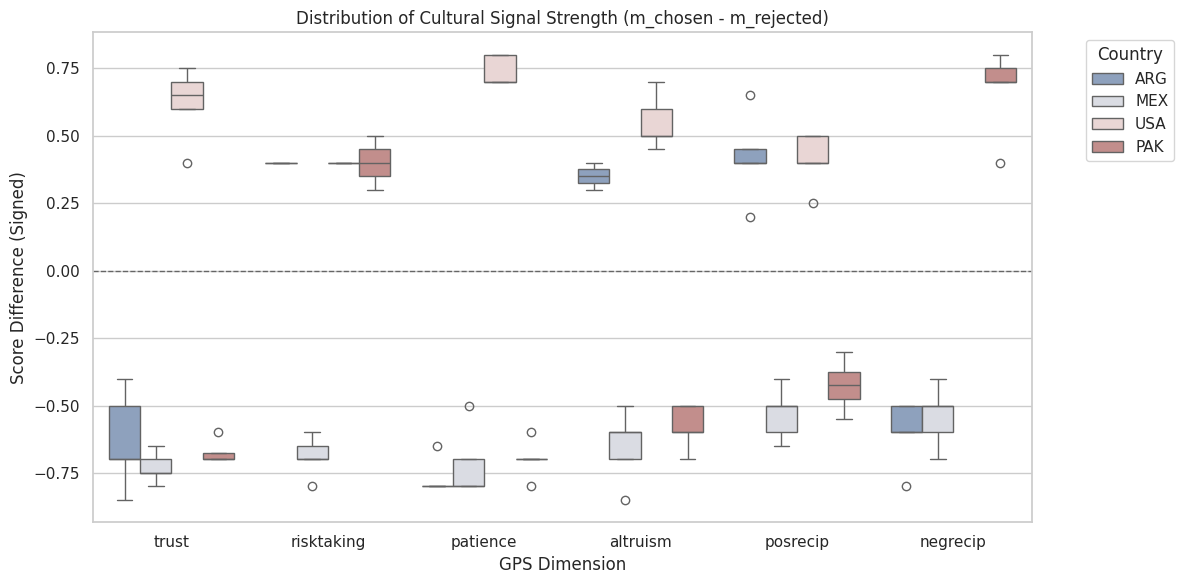

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set style
sns.set_theme(style="whitegrid")

# 1. Signal Strength (Signed Margin) by Dimension & Country
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_final, x="gps_dimension", y="m_diff_signed", hue="country", palette="vlag")
plt.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
plt.title("Distribution of Cultural Signal Strength (m_chosen - m_rejected)")
plt.ylabel("Score Difference (Signed)")
plt.xlabel("GPS Dimension")
plt.legend(title="Country", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# positive GPS -> Above zero, and vice versa. Wider spread -> More uncertainty when distinguishing cultural traits

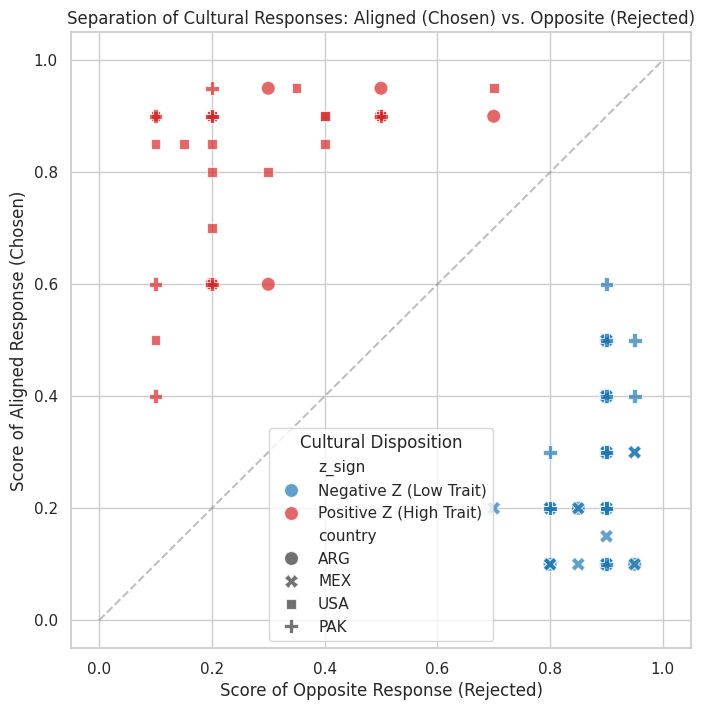

In [ ]:
# 2. Separation Analysis: Chosen vs. Rejected Scores
# We color points by whether the Country's Z-score for that dimension is Positive or Negative.
# Ideally:
# - Positive Z (Red): Aligned > Opposite -> Points below/right of diagonal (if x=rejected, y=chosen)
# - Negative Z (Blue): Aligned < Opposite -> Points above/left of diagonal

df_final['z_sign'] = np.where(df_final['z_value'] >= 0, 'Positive Z (High Trait)', 'Negative Z (Low Trait)')

plt.figure(figsize=(8, 8))
sns.scatterplot(data=df_final, x="m_rejected", y="m_chosen", hue="z_sign", style="country", palette={"Positive Z (High Trait)": "#d62728", "Negative Z (Low Trait)": "#1f77b4"}, s=100, alpha=0.7)

# Add diagonal identity line
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', alpha=0.5)
plt.title("Separation of Cultural Responses: Aligned (Chosen) vs. Opposite (Rejected)")
plt.xlabel("Score of Opposite Response (Rejected)")
plt.ylabel("Score of Aligned Response (Chosen)")
plt.legend(title="Cultural Disposition")
plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)
plt.show()

# very clear separation:
## Red -> Aligned response scores higher than Opposite -> Top-Left
## Blue -> Aligned responses score lower than Opposite to reflect "low trait value" -> Bottom-Right

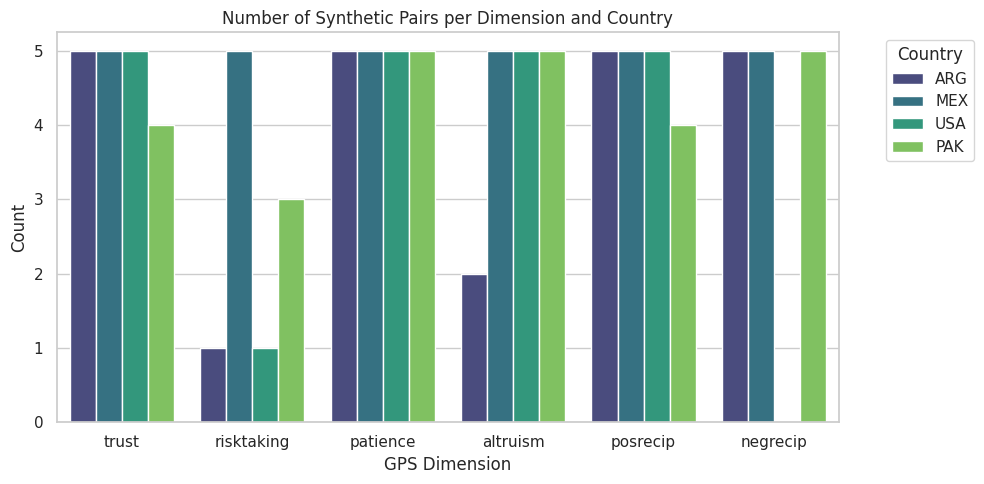

In [ ]:
# 3. Dataset Balance (Count of pairs)
plt.figure(figsize=(10, 5))
sns.countplot(data=df_final, x="gps_dimension", hue="country", palette="viridis")
plt.title("Number of Synthetic Pairs per Dimension and Country")
plt.ylabel("Count")
plt.xlabel("GPS Dimension")
plt.legend(title="Country", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Design Notes

We chose to condition generation on the **Global Preferences Survey (GPS)** rather than
vague persona prompts ("act like an Argentine") because GPS provides a quantified, six-dimensional
behavioral profile grounded in incentivized experimental measures. This gives us a concrete
state vector $z_c$ to condition on and to validate against.

We use **contrastive pair generation** (aligned vs. opposite in a single call) rather than
generating single responses and scoring them with a separate reward model. This is both cheaper
(one call, not two) and avoids the "strawman" problem — generating both responses simultaneously
forces the teacher to make the contrasting response equally articulate.

**Same-model scoring** is a pragmatic choice: using the same model family (Claude Sonnet) for
both generation and scoring avoids the need to calibrate across model families. We acknowledge
this creates a self-preference risk. An independent scorer or human validation (target:
Krippendorff's $\alpha \geq 0.7$) is a planned follow-up.

**Single-dimension QC filtering with 6D scoring** preserves backward compatibility while
enabling cross-dimensional analysis. The monotonicity filter operates only on the target
dimension, while the contamination ratio $C_k$ serves as a diagnostic — high values indicate
the scorer may be conflating dimensions, warranting per-dimension scoring in a future iteration.

**Known proxy weakness:** Patience and positive reciprocity have the weakest WVS proxy coverage
(3-4 items each, with non-significant correlations for patience). J-test power on these
dimensions will be limited. This is documented and accepted as a pre-registration constraint.

## Next Steps

### For the Fine-Tuning Handoff
Load the exported dataset with:
```python
from datasets import load_from_disk, Dataset
ds = load_from_disk("D_syn_combined_hf")  # or Dataset.from_json("D_syn_ARG.jsonl")
```
Configure `DPOTrainer` (TRL >= 0.8) with the suggested hyperparameters from `manifest.json`.

### Scaling to Full Run (~10K pairs)
1. Set `CONFIG["scenarios_per_dim"] = 170` (170 scenarios x 6 dims x 4 countries = 4,080 raw pairs)
2. Use `cost_tracker.estimate_full_run(170, 4)` to project costs before committing
3. Add trigram Jaccard deduplication to scenario bank
4. Run Pre-Training Bias Tests 1 and 5 (WEIRD audit + label swap consistency)
5. Monitor contamination ratios — if mean $C_k > 3.0$, consider per-dimension scoring

### Completed in v3 (previously listed as next steps)
- [x] 6-dimensional scoring with cross-contamination analysis
- [x] Error handling (`return_exceptions=True`, per-pair exception logging)
- [x] Cost estimation module for production run planning

### Known Limitations (Document in Paper 2)
- **Positive reciprocity:** Only 3 WVS proxy items; J-test power will be low.
- **No human validation:** Scorer not yet benchmarked against human raters (Krippendorff's $\alpha \geq 0.7$ target).
- **Same-model scoring:** Self-preference bias risk (generation and scoring use same model family).